# 05. 추천 스코어링 로직
- 입력: `output/tour_clustered.csv`, `output/visitor_clean.csv`
- 출력: `output/scoring_result.csv` (관광지별 스코어 + 추천 후보)
- **셀 순서대로 실행하면 됩니다**

In [1]:
# ── 셀 1: 라이브러리 + 데이터 로드 ──────────────────────────
import pandas as pd
import numpy as np
from pathlib import Path
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('./output')

# 클러스터링 결과 로드
df = pd.read_csv(OUTPUT_DIR / 'tour_clustered.csv')
# visitor 데이터 로드
visitor = pd.read_csv(OUTPUT_DIR / 'visitor_clean.csv')

print(f'tour_clustered: {len(df):,}건')
print(f'visitor_clean : {len(visitor):,}행')
print(f'\ntour_clustered 컬럼: {list(df.columns)}')

tour_clustered: 19,223건
visitor_clean : 710,640행

tour_clustered 컬럼: ['content_id', 'content_type_id', 'content_type_name', 'name', 'address', 'area_code', 'sigungu_code', 'cat1', 'cat2', 'cat3', 'longitude', 'latitude', 'tel', 'image_url', 'cat2_name', 'area_name', 'space_cluster', 'cat2_filled', 'cluster_theme', 'cluster_area', 'cluster_lat', 'cluster_lon', 'cluster_size', 'cluster_id', 'avg_monthly_visitors']


In [3]:
print(sorted(visitor['ym'].unique())[-6:])

['2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']


## 1. 혼잡도 점수 계산
- 기준: 2016~2019년 월평균 방문객 (코로나 전 노멀)
- 최근 12개월 평균 vs 기준 대비 배율 계산
- 혼잡도가 높을수록 낮은 점수 (0~1 역정규화)

In [4]:
# ── 셀 2: 혼잡도 기준선 계산 (2016~2019 월평균) ─────────────
baseline = (
    visitor[
        visitor['year'].between(2016, 2019) &
        visitor['visitors_total'].notna()
    ]
    .groupby('site')['visitors_total']
    .mean()
    .reset_index()
    .rename(columns={'visitors_total': 'baseline_monthly', 'site': 'name'})
)

# 최근 12개월 평균 방문객
recent_ym = sorted(visitor['ym'].unique())[-12:]
recent = (
    visitor[
        visitor['ym'].isin(recent_ym) &
        visitor['visitors_total'].notna()
    ]
    .groupby('site')['visitors_total']
    .mean()
    .reset_index()
    .rename(columns={'visitors_total': 'recent_monthly', 'site': 'name'})
)

congestion_df = baseline.merge(recent, on='name', how='outer')

# 혼잡 배율
congestion_df['congestion_ratio'] = (
    congestion_df['recent_monthly'] / congestion_df['baseline_monthly']
).clip(0, 10)

# ✅ B안: recent=0 이고 baseline>0 이면 폐업/미집계로 보고 0.5 처리
mask_zero_recent = (
    (congestion_df['recent_monthly'] == 0) &
    (congestion_df['baseline_monthly'] > 0)
)
congestion_df['congestion_score'] = 1 / (1 + congestion_df['congestion_ratio'])
congestion_df.loc[mask_zero_recent, 'congestion_score'] = 0.5
congestion_df.loc[mask_zero_recent, 'congestion_ratio'] = np.nan

# 데이터 없으면 기본값 0.5
congestion_df['congestion_score'] = congestion_df['congestion_score'].fillna(0.5)

print(f'혼잡도 계산 완료: {len(congestion_df):,}개 관광지')
print(f'폐업/미집계 보정: {mask_zero_recent.sum()}개')
print(f'\n혼잡 배율 분포:')
print(congestion_df['congestion_ratio'].describe().round(2))
print(f'\n혼잡도 점수 샘플 (상위 10개 - 실제 한산한 곳):')
print(congestion_df[~mask_zero_recent].nlargest(10, 'congestion_score')[
    ['name','baseline_monthly','recent_monthly','congestion_ratio','congestion_score']
].to_string())

혼잡도 계산 완료: 4,170개 관광지
폐업/미집계 보정: 235개

혼잡 배율 분포:
count    3889.00
mean        1.33
std         1.73
min         0.00
25%         0.65
50%         1.00
75%         1.12
max        10.00
Name: congestion_ratio, dtype: float64

혼잡도 점수 샘플 (상위 10개 - 실제 한산한 곳):
                 name  baseline_monthly  recent_monthly  congestion_ratio  congestion_score
1552          보령머드박물관       6023.562500        5.000000          0.000830          0.999171
3663              태사묘       2191.958333        6.000000          0.002737          0.997270
2837               웅도        500.000000        1.416667          0.002833          0.997175
2483          에덴밸리 루지      13124.541667       73.000000          0.005562          0.994469
251          계방산(평창군)       3755.479167       24.000000          0.006391          0.993650
2865          월곡역사박물관        296.708333        2.000000          0.006741          0.993305
3414           채일봉전망대        202.000000        1.833333          0.009076          0.991006
3277   주

In [5]:
# ── 셀 3: tour_clustered에 혼잡도 점수 병합 ─────────────────
df = df.merge(congestion_df[['name','baseline_monthly','recent_monthly','congestion_ratio','congestion_score']], 
              on='name', how='left')

# 매칭 안 된 관광지는 중간 혼잡도(0.5) 부여
df['congestion_score'] = df['congestion_score'].fillna(0.5)

matched = df['congestion_ratio'].notna().sum()
print(f'혼잡도 매칭: {matched:,}개 ({matched/len(df)*100:.1f}%)')
print(f'미매칭(기본값 0.5 적용): {len(df)-matched:,}개')

혼잡도 매칭: 1,132개 (5.9%)
미매칭(기본값 0.5 적용): 18,091개


In [22]:
# ── 셀 3-1: 수동 매칭 보완 ───────────────────────────────────
manual_match = {
    '해운대해수욕장': '해운대관광특구(해운대구)',
    '성산일출봉 [유네스코 세계자연유산]': '성산일출봉',
}

for tour_name, visitor_name in manual_match.items():
    score_row = congestion_df[congestion_df['name'] == visitor_name]
    if score_row.empty:
        print(f'❌ visitor에서 못 찾음: {visitor_name}')
        continue
    score = score_row.iloc[0]['congestion_score']
    ratio = score_row.iloc[0]['congestion_ratio']
    recent = score_row.iloc[0]['recent_monthly']
    baseline = score_row.iloc[0]['baseline_monthly']
    
    df.loc[df['name'] == tour_name, 'congestion_score'] = score
    df.loc[df['name'] == tour_name, 'congestion_ratio'] = ratio
    df.loc[df['name'] == tour_name, 'recent_monthly'] = recent
    df.loc[df['name'] == tour_name, 'baseline_monthly'] = baseline
    df.loc[df['name'] == tour_name, 'avg_monthly_visitors'] = baseline
    
    print(f'✅ {tour_name} → {visitor_name} | congestion_score={score:.3f}')

✅ 해운대해수욕장 → 해운대관광특구(해운대구) | congestion_score=0.500
✅ 성산일출봉 [유네스코 세계자연유산] → 성산일출봉 | congestion_score=0.710


In [ ]:
# ── 셀 3-2: 퍼지 매칭으로 visitor 매칭률 개선 ────────────────
from rapidfuzz import process, fuzz

# visitor 사이트 이름 목록
visitor_sites = visitor['site'].unique().tolist()

# 현재 미매칭인 tour 관광지만 대상
unmatched = df[df['avg_monthly_visitors'].isna()]['name'].unique()
print(f'퍼지 매칭 대상: {len(unmatched):,}개')

fuzzy_results = []

for name in unmatched:
    match = process.extractOne(
        name, 
        visitor_sites, 
        scorer=fuzz.token_sort_ratio,
        score_cutoff=90  # 90점 이상만 매칭
    )
    if match:
        fuzzy_results.append({
            'tour_name': name,
            'visitor_name': match[0],
            'score': match[1]
        })

fuzzy_df = pd.DataFrame(fuzzy_results)
print(f'매칭 성공: {len(fuzzy_df):,}개')
print(f'\n샘플 (상위 20개):')
print(fuzzy_df.head(20).to_string(index=False))

퍼지 매칭 대상: 18,010개
매칭 성공: 188개

샘플 (상위 20개):
  tour_name visitor_name     score
    감악산(파주)     감악산(파주시) 93.333333
   강릉 솔향수목원      강릉솔향수목원 93.333333
  강씨봉 자연휴양림     강씨봉자연휴양림 94.117647
거일1리 어촌체험마을   거일1리어촌체험마을 95.238095
  거제 관광모노레일     거제관광모노레일 94.117647
   거창사건추모공원    거창사건 추모공원 94.117647
    경기도자미술관       경기도미술관 92.307692
   경암동 철길마을      경암동철길마을 93.333333
     경주 동궁원        경주동궁원 90.909091
     경주 첨성대        경주첨성대 90.909091
  계명산 자연휴양림     계명산자연휴양림 94.117647
    계방산(평창)     계방산(평창군) 93.333333
   과일나라테마공원    과일나라 테마공원 94.117647
    광안리해수욕장     광안리 해수욕장 93.333333
 괴산 한지체험박물관    괴산한지체험박물관 94.736842
   괴시리 전통마을      괴시리전통마을 93.333333
    구병리아름마을     구병리 아름마을 93.333333
    구봉산 전망대       구봉산전망대 92.307692
   구재봉자연휴양림    구재봉 자연휴양림 94.117647
 구포 어린이교통공원    구포어린이교통공원 94.736842


In [30]:
# ── 셀 3-3: 퍼지 매칭 결과 df에 적용 ────────────────────────
before = df['avg_monthly_visitors'].notna().sum()

for _, row in fuzzy_df.iterrows():
    tour_name    = row['tour_name']
    visitor_name = row['visitor_name']
    
    score_row = congestion_df[congestion_df['name'] == visitor_name]
    if score_row.empty:
        continue
    
    s = score_row.iloc[0]
    df.loc[df['name'] == tour_name, 'congestion_score']      = s['congestion_score']
    df.loc[df['name'] == tour_name, 'congestion_ratio']      = s['congestion_ratio']
    df.loc[df['name'] == tour_name, 'avg_monthly_visitors']  = s['baseline_monthly']

after = df['avg_monthly_visitors'].notna().sum()
print(f'매칭 전: {before:,}개')
print(f'매칭 후: {after:,}개')
print(f'추가 매칭: +{after-before:,}개')
print(f'전체 매칭률: {after/len(df)*100:.1f}%')

매칭 전: 1,163개
매칭 후: 1,351개
추가 매칭: +188개
전체 매칭률: 7.0%


## 2. 거리 점수 + 테마 일치 점수
- haversine 거리 계산
- 30km 초과 후보 제외
- 가까울수록 높은 점수 (선형 역정규화)
- cat2 동일: 1.0 / cat1 동일: 0.5 / 불일치: 0.0

In [6]:
# ── 셀 4: haversine 거리 함수 ────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    """두 좌표 간 거리(km) 계산"""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def distance_score(dist_km, max_km=30):
    """거리 점수: 0~max_km → 1~0 선형"""
    if dist_km > max_km:
        return None  # 후보 제외
    return 1.0 - (dist_km / max_km)

def theme_score(origin_cat1, origin_cat2, cand_cat1, cand_cat2):
    """테마 일치 점수"""
    if pd.notna(origin_cat2) and pd.notna(cand_cat2) and origin_cat2 == cand_cat2:
        return 1.0
    if pd.notna(origin_cat1) and pd.notna(cand_cat1) and origin_cat1 == cand_cat1:
        return 0.5
    return 0.0

print('✅ 거리/테마 함수 정의 완료')

# 거리 점수 테스트
print(f'\n거리 점수 테스트:')
for d in [0, 5, 10, 15, 20, 25, 30, 31]:
    s = distance_score(d)
    print(f'  {d:2d}km → {s}')

✅ 거리/테마 함수 정의 완료

거리 점수 테스트:
   0km → 1.0
   5km → 0.8333333333333334
  10km → 0.6666666666666667
  15km → 0.5
  20km → 0.33333333333333337
  25km → 0.16666666666666663
  30km → 0.0
  31km → None


## 3. 추천 함수 구현
특정 관광지(origin)를 입력하면 → 대안 후보 반환

**최종 스코어 = 혼잡도(0.4) + 거리(0.4) + 테마(0.2)**

In [7]:
# ── 셀 5: 추천 함수 ──────────────────────────────────────────
W_CONGESTION = 0.4
W_DISTANCE   = 0.4
W_THEME      = 0.2
MAX_DIST_KM  = 30

def recommend(origin_name: str, top_n: int = 5) -> pd.DataFrame:
    """
    origin_name: 원래 목적지 관광지 이름
    top_n: 반환할 추천 수
    """
    # 원래 관광지 조회
    origin_rows = df[df['name'] == origin_name]
    if origin_rows.empty:
        print(f'❌ 관광지를 찾을 수 없습니다: {origin_name}')
        # 유사 이름 검색
        candidates = df[df['name'].str.contains(origin_name[:2], na=False)]['name'].unique()[:5]
        if len(candidates):
            print(f'   유사 관광지: {list(candidates)}')
        return pd.DataFrame()
    
    origin = origin_rows.iloc[0]
    o_lat   = origin['latitude']
    o_lon   = origin['longitude']
    o_cat1  = origin.get('cat1', None)
    o_cat2  = origin.get('cat2', None)
    
    results = []
    
    for _, cand in df.iterrows():
        # 자기 자신 제외
        if cand['name'] == origin_name:
            continue
        
        c_lat = cand['latitude']
        c_lon = cand['longitude']
        
        # 위경도 없으면 스킵
        if pd.isna(c_lat) or pd.isna(c_lon):
            continue
        
        # 거리 계산
        dist = haversine_km(o_lat, o_lon, c_lat, c_lon)
        d_score = distance_score(dist, MAX_DIST_KM)
        
        # 30km 초과 제외
        if d_score is None:
            continue
        
        # 테마 점수
        t_score = theme_score(o_cat1, o_cat2, cand.get('cat1'), cand.get('cat2'))
        
        # 혼잡도 점수 (이미 df에 있음)
        c_score = cand.get('congestion_score', 0.5)
        
        # 최종 스코어
        final = W_CONGESTION * c_score + W_DISTANCE * d_score + W_THEME * t_score
        
        results.append({
            'name':             cand['name'],
            'address':          cand.get('address', ''),
            'cluster_theme':    cand.get('cluster_theme', ''),
            'cat2':             cand.get('cat2', ''),
            'dist_km':          round(dist, 2),
            'congestion_score': round(float(c_score), 3),
            'distance_score':   round(d_score, 3),
            'theme_score':      t_score,
            'final_score':      round(final, 3),
            'latitude':         c_lat,
            'longitude':        c_lon,
            'image_url':        cand.get('image_url', ''),
        })
    
    result_df = pd.DataFrame(results).sort_values('final_score', ascending=False)
    return result_df.head(top_n).reset_index(drop=True)

print('✅ recommend() 함수 정의 완료')

✅ recommend() 함수 정의 완료


In [12]:
# ── 셀 6: 추천 테스트 ────────────────────────────────────────
test_sites = [
    '경복궁',
    '해운대해수욕장',
    '성산일출봉 [유네스코 세계자연유산]',
    '남이섬',
    '전북 전주 한옥마을 [슬로시티]',
]

for site in test_sites:
    sep = '='*60
    print(f'\n{sep}')
    print(f'🏛️  [{site}] 대안 추천 TOP 5')
    print(sep)
    result = recommend(site, top_n=5)
    if not result.empty:
        display_cols = ['name','dist_km','congestion_score','distance_score','theme_score','final_score','cluster_theme']
        print(result[display_cols].to_string(index=False))


🏛️  [경복궁] 대안 추천 TOP 5
                   name  dist_km  congestion_score  distance_score  theme_score  final_score cluster_theme
              한복남 프리미엄점     0.31               0.5           0.990          0.5        0.696          문화시설
              열린송현 녹지광장     0.42               0.5           0.986          0.5        0.694          문화시설
            한국사찰음식문화체험관     0.63               0.5           0.979          0.5        0.692          문화시설
국립민속박물관과 국립민속박물관 어린이박물관     0.66               0.5           0.978          0.5        0.691          문화시설
             종로 청계 관광특구     0.77               0.5           0.974          0.5        0.690          문화시설

🏛️  [해운대해수욕장] 대안 추천 TOP 5
    name  dist_km  congestion_score  distance_score  theme_score  final_score cluster_theme
    송림공원     0.60               0.5           0.980          0.5        0.692          문화시설
     할매탕     0.61               0.5           0.980          0.5        0.692          문화시설
    해리단길     0.68               

In [13]:
for site in ['성산일출봉 [유네스코 세계자연유산]', '남이섬']:
    sep = '='*60
    print(f'\n{sep}')
    print(f'[{site}] 대안 추천 TOP 5')
    print(sep)
    result = recommend(site, top_n=5)
    if not result.empty:
        display_cols = ['name','dist_km','congestion_score','distance_score','theme_score','final_score','cluster_theme']
        pd.set_option('display.max_rows', 20)
        pd.set_option('display.width', 200)
        print(result[display_cols].to_string(index=False))


[성산일출봉 [유네스코 세계자연유산]] 대안 추천 TOP 5
   name  dist_km  congestion_score  distance_score  theme_score  final_score cluster_theme
  광치기해변     1.73               0.5           0.942          1.0        0.777         자연관광지
 제주 성산항     1.93               0.5           0.936          1.0        0.774         자연관광지
  졸띠유채밭     2.26               0.5           0.925          1.0        0.770         자연관광지
   오조포구     2.46               0.5           0.918          1.0        0.767         자연관광지
짱구네유채꽃밭     2.51               0.5           0.916          1.0        0.767         자연관광지

[남이섬] 대안 추천 TOP 5
    name  dist_km  congestion_score  distance_score  theme_score  final_score cluster_theme
    백풍밀원     0.00             0.500           1.000          0.5        0.700           레포츠
   제이드가든     4.27             0.631           0.858          0.5        0.695           관광지
 자라섬 이화원     2.49             0.500           0.917          0.5        0.667         육상레포츠
     자라섬     2.77             0.

## 4. 성능 최적화: 벡터화 버전
위의 row-by-row 방식은 19,223건에 대해 느림 → numpy 벡터화로 개선

In [31]:
# ── 셀 7: 벡터화 haversine + 빠른 추천 함수 ─────────────────
import numpy as np

# 미리 numpy 배열로 변환 (속도 최적화)
lats = np.radians(df['latitude'].values)
lons = np.radians(df['longitude'].values)
names_arr = df['name'].values

def haversine_vec(o_lat_rad, o_lon_rad, lats_rad, lons_rad):
    """벡터화 haversine: 1개 원점 vs 전체 배열"""
    R = 6371.0
    dlat = lats_rad - o_lat_rad
    dlon = lons_rad - o_lon_rad
    a = np.sin(dlat/2)**2 + np.cos(o_lat_rad) * np.cos(lats_rad) * np.sin(dlon/2)**2
    a = np.clip(a, 0, 1)
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def recommend_fast(origin_name: str, top_n: int = 5) -> pd.DataFrame:
    """
    벡터화 버전 추천 함수 (속도 ~100x 개선)
    """
    origin_rows = df[df['name'] == origin_name]
    if origin_rows.empty:
        print(f'❌ 관광지를 찾을 수 없습니다: {origin_name}')
        candidates = df[df['name'].str.contains(origin_name[:2], na=False)]['name'].unique()[:5]
        if len(candidates):
            print(f'   유사 관광지: {list(candidates)}')
        return pd.DataFrame()
    
    origin = origin_rows.iloc[0]
    o_lat = radians(origin['latitude'])
    o_lon = radians(origin['longitude'])
    o_cat1 = origin.get('cat1', None)
    o_cat2 = origin.get('cat2', None)
    
    # 벡터화 거리 계산
    dists = haversine_vec(o_lat, o_lon, lats, lons)
    
    # 30km 이내 마스크 (자기 자신 제외)
    mask = (dists <= MAX_DIST_KM) & (names_arr != origin_name)
    
    sub = df[mask].copy()
    sub_dists = dists[mask]
    
    if len(sub) == 0:
        print(f'⚠️  30km 이내 후보 없음')
        return pd.DataFrame()
    
    # 거리 점수
    sub['dist_km']       = sub_dists
    sub['distance_score'] = 1.0 - (sub_dists / MAX_DIST_KM)
    
    # 테마 점수 (벡터화)
    sub['theme_score'] = 0.0
    if pd.notna(o_cat2):
        sub.loc[sub['cat2'] == o_cat2, 'theme_score'] = 1.0
    if pd.notna(o_cat1):
        sub.loc[(sub['cat1'] == o_cat1) & (sub['theme_score'] < 1.0), 'theme_score'] = 0.5
    
    # 최종 스코어
    sub['final_score'] = (
        W_CONGESTION * sub['congestion_score'] +
        W_DISTANCE   * sub['distance_score'] +
        W_THEME      * sub['theme_score']
    )
    
    cols = ['name','address','cluster_theme','cat2','dist_km',
            'congestion_score','distance_score','theme_score','final_score',
            'latitude','longitude','image_url']
    available_cols = [c for c in cols if c in sub.columns]
    
    return sub[available_cols].sort_values('final_score', ascending=False).head(top_n).reset_index(drop=True)

print('✅ recommend_fast() 정의 완료')

✅ recommend_fast() 정의 완료


In [15]:
# ── 셀 8: 속도 비교 테스트 ───────────────────────────────────
import time

test_name = '경복궁'

# 느린 버전
t0 = time.time()
r1 = recommend(test_name, top_n=5)
t1 = time.time()
print(f'기본 버전: {t1-t0:.2f}초')

# 빠른 버전
t0 = time.time()
r2 = recommend_fast(test_name, top_n=5)
t1 = time.time()
print(f'벡터화 버전: {t1-t0:.2f}초')

print(f'\n결과 (벡터화 버전):')
display_cols = ['name','dist_km','congestion_score','distance_score','theme_score','final_score']
print(r2[display_cols].to_string(index=False))

기본 버전: 0.35초
벡터화 버전: 0.01초

결과 (벡터화 버전):
                   name  dist_km  congestion_score  distance_score  theme_score  final_score
              한복남 프리미엄점 0.310488               0.5        0.989650          0.5     0.695860
              열린송현 녹지광장 0.417100               0.5        0.986097          0.5     0.694439
            한국사찰음식문화체험관 0.626188               0.5        0.979127          0.5     0.691651
국립민속박물관과 국립민속박물관 어린이박물관 0.656005               0.5        0.978133          0.5     0.691253
            하이드앤시크 쌈지길점 0.743243               0.5        0.975225          0.5     0.690090


## 5. 전체 관광지 사전 계산 (배치 스코어링)
웹 데모 MVP를 위해 전체 관광지에 대한 Top-10 추천을 미리 계산해 저장

In [32]:
# ── 셀 9: 배치 스코어링 (전체 관광지 Top-10 미리 계산) ────────
# ⚠️ 19,223건 × 19,223건 브루트포스는 무겁습니다.
# visitor 매칭된 관광지(1,161개)만 origin으로 계산
# → 웹 데모에서 검색 가능한 관광지를 이 1,161개로 제한

origin_sites = df[df['avg_monthly_visitors'].notna()]['name'].unique()
print(f'배치 대상: {len(origin_sites):,}개 관광지 (visitor 매칭된 곳만)')
print('예상 소요 시간: 약 1~3분')

batch_results = []

for i, site_name in enumerate(origin_sites):
    if i % 100 == 0:
        print(f'  진행: {i}/{len(origin_sites)}')
    
    recs = recommend_fast(site_name, top_n=10)
    if recs.empty:
        continue
    
    recs.insert(0, 'origin_name', site_name)
    recs.insert(1, 'rank', range(1, len(recs)+1))
    batch_results.append(recs)

batch_df = pd.concat(batch_results, ignore_index=True)
print(f'\n✅ 배치 완료: {len(batch_df):,}행')
print(f'  원점 관광지: {batch_df["origin_name"].nunique():,}개')
print(batch_df.head(10).to_string())

배치 대상: 1,345개 관광지 (visitor 매칭된 곳만)
예상 소요 시간: 약 1~3분
  진행: 0/1345
  진행: 100/1345
  진행: 200/1345
  진행: 300/1345
  진행: 400/1345
  진행: 500/1345
  진행: 600/1345
  진행: 700/1345
  진행: 800/1345
  진행: 900/1345
  진행: 1000/1345
  진행: 1100/1345
  진행: 1200/1345
  진행: 1300/1345

✅ 배치 완료: 13,431행
  원점 관광지: 1,345개
  origin_name  rank         name                      address cluster_theme   cat2   dist_km  congestion_score  distance_score  theme_score  final_score   latitude   longitude                                                           image_url
0         가거도     1       동개해수욕장            전라남도 신안군 흑산면 가거도리           관광지    NaN  0.564528               0.5        0.981182          0.5     0.692473  34.049454  125.131644  https://tong.visitkorea.or.kr/cms/resource/59/4054459_image2_1.jpg
1         가거도     2          독실산            전라남도 신안군 흑산면 가거도리           관광지    NaN  3.108121               0.5        0.896396          0.5     0.658558  34.075867  125.108703  https://tong.visitkorea.or.kr/cms/re

In [33]:
# ── 셀 10: 결과 저장 ─────────────────────────────────────────
out_path = OUTPUT_DIR / 'scoring_result.csv'
batch_df.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'✅ 저장: {out_path}')
print(f'   행 수: {len(batch_df):,}')
print(f'   컬럼: {list(batch_df.columns)}')

✅ 저장: output\scoring_result.csv
   행 수: 13,431
   컬럼: ['origin_name', 'rank', 'name', 'address', 'cluster_theme', 'cat2', 'dist_km', 'congestion_score', 'distance_score', 'theme_score', 'final_score', 'latitude', 'longitude', 'image_url']


## 6. 검증: 결과 샘플 확인

In [37]:
# ── 셀 11: 검증 ──────────────────────────────────────────────
validate_sites = ['경복궁', '해운대해수욕장', '성산일출봉 [유네스코 세계자연유산]']

for site in validate_sites:
    sep = '='*60
    subset = batch_df[batch_df['origin_name'] == site]
    if subset.empty:
        print(f'[{site}] 결과 없음')
        continue
    print(f'\n{sep}')
    print(f'[{site}] 추천 결과')
    print(sep)
    print(subset[['rank','name','dist_km','congestion_score',
                  'distance_score','theme_score','final_score','cluster_theme']]
          .to_string(index=False))


[경복궁] 추천 결과
 rank                    name  dist_km  congestion_score  distance_score  theme_score  final_score cluster_theme
    1               한복남 프리미엄점 0.310488               0.5        0.989650          0.5     0.695860          문화시설
    2               열린송현 녹지광장 0.417100               0.5        0.986097          0.5     0.694439          문화시설
    3             한국사찰음식문화체험관 0.626188               0.5        0.979127          0.5     0.691651          문화시설
    4 국립민속박물관과 국립민속박물관 어린이박물관 0.656005               0.5        0.978133          0.5     0.691253          문화시설
    5             하이드앤시크 쌈지길점 0.743243               0.5        0.975225          0.5     0.690090          문화시설
    6              종로 청계 관광특구 0.765997               0.5        0.974467          0.5     0.689787          문화시설
    7                 뮤지엄 김치간 0.768683               0.5        0.974377          0.5     0.689751          문화시설
    8                 한복남 북촌점 0.824272               0.5        0.972524          0

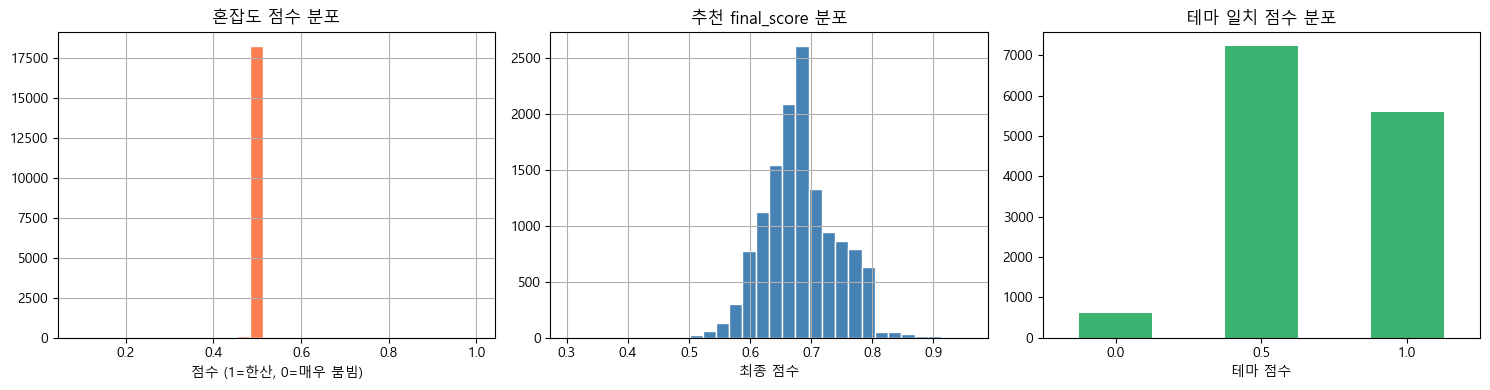

✅ 시각화 저장: output/scoring_overview.png


In [38]:
# ── 셀 12: 스코어 분포 시각화 ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 혼잡도 점수 분포
df['congestion_score'].hist(bins=30, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('혼잡도 점수 분포')
axes[0].set_xlabel('점수 (1=한산, 0=매우 붐빔)')

# 추천 결과의 최종 스코어 분포
batch_df['final_score'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('추천 final_score 분포')
axes[1].set_xlabel('최종 점수')

# 테마 점수 분포
batch_df['theme_score'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('테마 일치 점수 분포')
axes[2].set_xlabel('테마 점수')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scoring_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 시각화 저장: output/scoring_overview.png')

## 요약

| 산출물 | 경로 | 설명 |
|--------|------|------|
| `scoring_result.csv` | `output/` | visitor 매칭 관광지별 Top-10 추천 사전계산 결과 |
| `scoring_overview.png` | `output/` | 스코어 분포 시각화 |

### 스코어링 로직 요약
```
final_score = 0.4 × congestion_score
            + 0.4 × distance_score
            + 0.2 × theme_score

혼잡도: 1 / (1 + 최근12개월평균/기준평균) → 붐빌수록 낮음
거리:   1 - (dist_km / 30km)            → 멀수록 낮음, 30km 초과 제외
테마:   cat2 동일=1.0, cat1 동일=0.5, 불일치=0.0
```

### 다음 단계: 웹 데모 MVP
- `scoring_result.csv`를 백엔드 DB 또는 JSON으로 변환
- Streamlit / FastAPI 기반 검색 UI 구현
- 영월 사례 연구 연결 (미디어 효과 → 혼잡도 급등 → 분산 추천)

# 05-B. 혼잡도 보완 — 계층적 Fallback

기존 05_scoring.ipynb 뒤에 이어서 실행하세요.

## 전략
```
1단계: 퍼지매칭 임계값 80으로 낮춰서 추가 매칭
2단계: 그래도 미매칭 → 같은 공간 클러스터 평균 대입
3단계: 클러스터에 데이터 없으면 → 같은 시도 평균 대입
4단계: 최후 fallback → 전국 평균
```
0.5 고정 대비 훨씬 현실적인 값이 채워집니다.

In [ ]:
# ── 셀 A-1: 현재 매칭 현황 파악 ─────────────────────────────
# 이 셀은 기존 05_scoring.ipynb가 실행된 상태에서 이어서 돌립니다
# df = tour_clustered + congestion_score가 붙어 있는 상태

import pandas as pd
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path('./output')

# 기존 df가 없으면 다시 로드
# (이미 메모리에 있으면 아래 두 줄 주석처리 가능)
df       = pd.read_csv(OUTPUT_DIR / 'tour_clustered.csv')
visitor  = pd.read_csv(OUTPUT_DIR / 'visitor_clean.csv')

print('=== 현재 매칭 현황 ===')
total = len(df)
matched = df['avg_monthly_visitors'].notna().sum()
print(f'전체 관광지     : {total:,}개')
print(f'혼잡도 데이터 있음: {matched:,}개 ({matched/total*100:.1f}%)')
print(f'혼잡도 데이터 없음: {total-matched:,}개 ({(total-matched)/total*100:.1f}%)')

print('\n=== 단독 관광지(클러스터 없음) 현황 ===')
solo = df[df['space_cluster'] == -1]
print(f'단독 관광지: {len(solo):,}개')
solo_matched = solo['avg_monthly_visitors'].notna().sum()
print(f'  - 데이터 있음: {solo_matched:,}개')
print(f'  - 데이터 없음: {len(solo)-solo_matched:,}개')

print('\n=== 클러스터별 실제 데이터 보유 현황 (상위 10개 클러스터) ===')
cluster_stats = df[df['space_cluster'] != -1].groupby('space_cluster').agg(
    size=('name', 'count'),
    has_data=('avg_monthly_visitors', lambda x: x.notna().sum())
).reset_index()
cluster_stats['ratio'] = cluster_stats['has_data'] / cluster_stats['size']
print(f'전체 클러스터 수: {len(cluster_stats):,}개')
print(f'데이터 1개 이상 있는 클러스터: {(cluster_stats["has_data"]>0).sum():,}개')
print(f'데이터 전혀 없는 클러스터   : {(cluster_stats["has_data"]==0).sum():,}개')
print(cluster_stats.sort_values('size', ascending=False).head(10).to_string(index=False))

In [ ]:
# ── 셀 A-2: 기존 혼잡도 컬럼 백업 ───────────────────────────
# 기존 05_scoring에서 만든 congestion_score를 백업해둡니다
# congestion_score 컬럼이 없으면 NaN으로 초기화

if 'congestion_score' not in df.columns:
    df['congestion_score'] = np.nan
    print('congestion_score 컬럼 없음 → NaN으로 초기화')
else:
    df['congestion_score_orig'] = df['congestion_score'].copy()
    n_orig = df['congestion_score'].notna().sum()
    print(f'기존 congestion_score 백업 완료 (데이터 있는 관광지: {n_orig:,}개)')

In [ ]:
# ── 셀 A-3: 혼잡도 기준값 재계산 ─────────────────────────────
# visitor_clean.csv에서 관광지별 혼잡도 점수를 다시 계산합니다
# (기존 05_scoring에서 이미 했다면 congestion_df가 메모리에 있을 수도 있음)

BASELINE_START = '2016-01'
BASELINE_END   = '2019-12'
RECENT_MONTHS  = 12  # 최근 N개월 평균

latest_ym = visitor['ym'].max()
print(f'visitor 데이터 최신월: {latest_ym}')

# 최근 12개월
recent_yms = sorted(visitor['ym'].unique())[-RECENT_MONTHS:]
print(f'최근 {RECENT_MONTHS}개월: {recent_yms[0]} ~ {recent_yms[-1]}')

# 기준 기간(코로나 전)
baseline = visitor[
    (visitor['ym'] >= BASELINE_START) & (visitor['ym'] <= BASELINE_END)
].groupby('site')['visitors_total'].mean().rename('baseline_monthly')

# 최근 기간
recent = visitor[
    visitor['ym'].isin(recent_yms)
].groupby('site')['visitors_total'].mean().rename('recent_monthly')

# 혼잡도 점수 계산
congestion_df = pd.concat([baseline, recent], axis=1).dropna()
congestion_df['congestion_ratio'] = congestion_df['recent_monthly'] / congestion_df['baseline_monthly']
congestion_df['congestion_score'] = 1 / (1 + congestion_df['congestion_ratio'])
congestion_df = congestion_df.reset_index().rename(columns={'site': 'name'})

print(f'\n혼잡도 계산 완료: {len(congestion_df):,}개 관광지')
print(congestion_df.head())

In [ ]:
# ── 셀 A-4: 1단계 — 정확 매칭 ───────────────────────────────

visitor_sites = congestion_df['name'].tolist()

# 정확 매칭
exact_map = congestion_df.set_index('name')[['congestion_score', 'congestion_ratio', 'baseline_monthly']]

df = df.copy()
df['congestion_score']   = np.nan
df['congestion_ratio']   = np.nan
df['avg_monthly_visitors'] = np.nan
df['match_method']       = 'none'  # 매칭 방법 추적용

exact_match_mask = df['name'].isin(exact_map.index)
df.loc[exact_match_mask, 'congestion_score']     = df.loc[exact_match_mask, 'name'].map(exact_map['congestion_score'])
df.loc[exact_match_mask, 'congestion_ratio']     = df.loc[exact_match_mask, 'name'].map(exact_map['congestion_ratio'])
df.loc[exact_match_mask, 'avg_monthly_visitors'] = df.loc[exact_match_mask, 'name'].map(exact_map['baseline_monthly'])
df.loc[exact_match_mask, 'match_method']         = 'exact'

n_exact = exact_match_mask.sum()
print(f'1단계 정확 매칭: {n_exact:,}개')

In [ ]:
# ── 셀 A-5: 2단계 — 퍼지 매칭 (임계값 80) ───────────────────
# thefuzz 없으면: pip install thefuzz python-Levenshtein

from thefuzz import process, fuzz

unmatched_mask = df['match_method'] == 'none'
unmatched_names = df.loc[unmatched_mask, 'name'].tolist()

print(f'퍼지 매칭 대상: {len(unmatched_names):,}개')
print('퍼지 매칭 중... (수 분 소요될 수 있음)')

fuzzy_results = []
for name in unmatched_names:
    match = process.extractOne(
        name,
        visitor_sites,
        scorer=fuzz.token_sort_ratio,
        score_cutoff=80   # 90 → 80으로 낮춤
    )
    if match:
        fuzzy_results.append({
            'tour_name'   : name,
            'visitor_name': match[0],
            'score'       : match[1]
        })

fuzzy_df = pd.DataFrame(fuzzy_results)
print(f'\n퍼지 매칭 성공: {len(fuzzy_df):,}개')

# 점수 구간별 분포 확인 — 80~89점 구간이 오매칭 위험지대
if len(fuzzy_df):
    bins = [80, 85, 90, 95, 100]
    fuzzy_df['score_bin'] = pd.cut(fuzzy_df['score'], bins=bins, right=True)
    print('\n점수 구간별 매칭 수:')
    print(fuzzy_df['score_bin'].value_counts().sort_index())
    print('\n80~84점 구간 샘플 (오매칭 확인용):')
    print(fuzzy_df[fuzzy_df['score'] < 85][['tour_name','visitor_name','score']].head(20).to_string(index=False))

In [ ]:
# ── 셀 A-6: 퍼지 매칭 결과 적용 ─────────────────────────────
# 위 셀에서 80~84점 샘플 확인 후 문제 없으면 이 셀 실행
# 오매칭이 많다면 FUZZY_THRESHOLD를 85로 올리세요

FUZZY_THRESHOLD = 80  # 필요시 조정

fuzzy_filtered = fuzzy_df[fuzzy_df['score'] >= FUZZY_THRESHOLD]

for _, row in fuzzy_filtered.iterrows():
    tour_name    = row['tour_name']
    visitor_name = row['visitor_name']
    score_row = congestion_df[congestion_df['name'] == visitor_name]
    if score_row.empty:
        continue
    s = score_row.iloc[0]
    idx = df[df['name'] == tour_name].index
    df.loc[idx, 'congestion_score']     = s['congestion_score']
    df.loc[idx, 'congestion_ratio']     = s['congestion_ratio']
    df.loc[idx, 'avg_monthly_visitors'] = s['baseline_monthly']
    df.loc[idx, 'match_method']         = f'fuzzy_{int(row["score"])}'

n_fuzzy = (df['match_method'].str.startswith('fuzzy')).sum()
print(f'2단계 퍼지 매칭 추가: {n_fuzzy:,}개')
print(f'현재까지 매칭률: {(df["match_method"] != "none").sum():,}개 / {len(df):,}개 ({(df["match_method"] != "none").sum()/len(df)*100:.1f}%)')

In [ ]:
# ── 셀 A-7: 3단계 — 클러스터 평균 대입 ──────────────────────
# 같은 공간 클러스터 내 실제 데이터 있는 관광지들의 혼잡도 평균

cluster_avg = (
    df[(df['space_cluster'] != -1) & (df['match_method'] != 'none')]
    .groupby('space_cluster')['congestion_score']
    .mean()
    .rename('cluster_avg_congestion')
)

print(f'혼잡도 평균 계산된 클러스터 수: {len(cluster_avg):,}개')

# 클러스터에 속하고 아직 미매칭인 관광지에 적용
cluster_fill_mask = (
    (df['match_method'] == 'none') &
    (df['space_cluster'] != -1) &
    (df['space_cluster'].isin(cluster_avg.index))
)

df.loc[cluster_fill_mask, 'congestion_score'] = \
    df.loc[cluster_fill_mask, 'space_cluster'].map(cluster_avg)
df.loc[cluster_fill_mask, 'match_method'] = 'cluster_avg'

n_cluster = cluster_fill_mask.sum()
print(f'3단계 클러스터 평균 대입: {n_cluster:,}개')
print(f'현재까지 매칭률: {(df["match_method"] != "none").sum():,}개 / {len(df):,}개 ({(df["match_method"] != "none").sum()/len(df)*100:.1f}%)')

In [ ]:
# ── 셀 A-8: 4단계 — 시도 평균 대입 ──────────────────────────
# 클러스터 평균도 없는 경우 (데이터 없는 클러스터, 단독 관광지)

sido_avg = (
    df[df['match_method'] != 'none']
    .groupby('area_name')['congestion_score']
    .mean()
    .rename('sido_avg_congestion')
)

print('시도별 평균 혼잡도:')
print(sido_avg.sort_values().to_string())

sido_fill_mask = df['match_method'] == 'none'
df.loc[sido_fill_mask, 'congestion_score'] = \
    df.loc[sido_fill_mask, 'area_name'].map(sido_avg)
df.loc[sido_fill_mask, 'match_method'] = 'sido_avg'

n_sido = sido_fill_mask.sum()
print(f'\n4단계 시도 평균 대입: {n_sido:,}개')

# 그래도 NaN 남아있으면 전국 평균으로 최종 fallback
national_avg = df[df['match_method'] != 'sido_avg']['congestion_score'].mean()
still_none = df['congestion_score'].isna()
df.loc[still_none, 'congestion_score'] = national_avg
df.loc[still_none, 'match_method'] = 'national_avg'

print(f'5단계 전국 평균 fallback: {still_none.sum():,}개 (전국 평균: {national_avg:.3f})')

In [ ]:
# ── 셀 A-9: 최종 결과 확인 ───────────────────────────────────

print('=== 매칭 방법별 분포 ===')
method_counts = df['match_method'].value_counts()
for method, count in method_counts.items():
    print(f'  {method:<20}: {count:,}개 ({count/len(df)*100:.1f}%)')

print(f'\n최종 NaN 수: {df["congestion_score"].isna().sum()}개')
print(f'\n혼잡도 점수 통계:')
print(df['congestion_score'].describe())

print('\n=== 방법별 혼잡도 평균 비교 ===')
print(df.groupby('match_method')['congestion_score'].agg(['mean','std','count']).round(3))

In [ ]:
# ── 셀 A-10: 보완된 df로 배치 스코어링 재실행 ───────────────
# 기존 recommend_fast() 함수가 메모리에 있는 상태에서 실행
# (없으면 05_scoring.ipynb의 recommend_fast 셀부터 다시 실행)

import numpy as np

# 전역 배열 업데이트 (recommend_fast가 참조하는 배열들)
lats      = df['latitude'].values
lons      = df['longitude'].values
names_arr = df['name'].values

# origin 대상: 실제 visitor 데이터가 있는 관광지만
# (클러스터/시도 평균으로 채운 곳은 origin에서 제외 — 혼잡도 신뢰도 낮음)
origin_sites = df[
    df['match_method'].isin(['exact']) | df['match_method'].str.startswith('fuzzy')
]['name'].unique()

print(f'배치 대상 (실제 데이터 있는 origin): {len(origin_sites):,}개')

batch_results = []
for i, site_name in enumerate(origin_sites):
    if i % 100 == 0:
        print(f'  진행: {i}/{len(origin_sites)}')
    recs = recommend_fast(site_name, top_n=10)
    if recs.empty:
        continue
    recs.insert(0, 'origin_name', site_name)
    recs.insert(1, 'rank', range(1, len(recs)+1))
    batch_results.append(recs)

batch_df_v2 = pd.concat(batch_results, ignore_index=True)
print(f'\n✅ 배치 완료: {len(batch_df_v2):,}행')
print(f'   원점 관광지: {batch_df_v2["origin_name"].nunique():,}개')

In [ ]:
# ── 셀 A-11: 결과 저장 ───────────────────────────────────────

# 보완된 clustered 저장 (match_method 컬럼 포함)
df.to_csv(OUTPUT_DIR / 'tour_clustered_v2.csv', index=False, encoding='utf-8-sig')
print('✅ 저장: output/tour_clustered_v2.csv')

# 보완된 스코어링 결과 저장
batch_df_v2.to_csv(OUTPUT_DIR / 'scoring_result_v2.csv', index=False, encoding='utf-8-sig')
print('✅ 저장: output/scoring_result_v2.csv')
print(f'   행 수: {len(batch_df_v2):,}')

# 기존 결과와 비교
try:
    old = pd.read_csv(OUTPUT_DIR / 'scoring_result.csv')
    print(f'\n=== 기존 vs 개선 비교 ===')
    print(f'origin 관광지 수: {old["origin_name"].nunique():,} → {batch_df_v2["origin_name"].nunique():,}')
    print(f'추천 행 수       : {len(old):,} → {len(batch_df_v2):,}')
    print(f'평균 final_score : {old["final_score"].mean():.4f} → {batch_df_v2["final_score"].mean():.4f}')
except:
    print('(기존 scoring_result.csv 없음)')

## 완료 후 할 것

`app.py`에서 `scoring_result.csv` → `scoring_result_v2.csv` 로 경로 수정,  
`tour_clustered.csv` → `tour_clustered_v2.csv` 로 경로 수정.

```python
# utils.py 수정
def load_data():
    scoring   = pd.read_csv('output/scoring_result_v2.csv')
    clustered = pd.read_csv('output/tour_clustered_v2.csv')
    return scoring, clustered
```

### match_method 컬럼 활용 (선택)
카드/테이블에 데이터 신뢰도를 표시할 수도 있음:
- `exact` / `fuzzy_NN` → 실제 데이터 기반 ✅
- `cluster_avg` → 클러스터 추정값 ⚠️
- `sido_avg` / `national_avg` → 지역 추정값 ℹ️